# 1. IMPORTACIÓN DE LIBRERÍAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

# 2. CARGA Y PREPROCESAMIENTO

In [ ]:
data = pd.read_csv("IMDB Dataset.csv")


data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})
data = data.dropna()


max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data['review'])
sequences = tokenizer.texts_to_sequences(data['review'])


X = pad_sequences(sequences, maxlen=max_len)
X = X.astype('float32') / max_words
y = data['sentiment'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Gráfico de Distribución de Clases

/tmp/ipykernel_15223/2555555065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis')


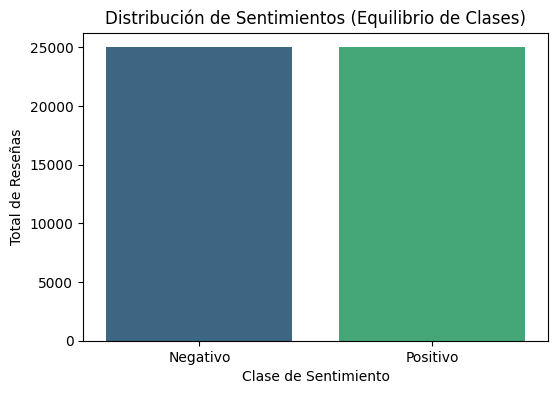

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=data, palette='viridis')
plt.title('Distribución de Sentimientos (Equilibrio de Clases)')
plt.xticks([0, 1], ['Negativo', 'Positivo']) # Esto cambia el 0 y 1 por texto
plt.xlabel('Clase de Sentimiento')
plt.ylabel('Total de Reseñas')
plt.show()

El gráfico de distribución de clases permite observar el balance entre las categorías positiva y negativa. En este caso, el dataset se encuentra relativamente balanceado, lo que facilita el entrenamiento del modelo sin necesidad de técnicas adicionales de balanceo.

# 3 Definición de Funciones y Arquitectura del Modelo (MLP)

In [ ]:
def crear_modelo_mlp(funcion_activacion='relu', tasa_dropout=0.0):
    """
    Crea una arquitectura de Red Neuronal Artificial (MLP).
    - Capa de Entrada: Flatten para transformar la matriz de secuencias.
    - Capas Ocultas: Dense con función de activación configurable.
    - Regularización: Dropout opcional para mejorar la estabilidad.
    - Capa de Salida: Sigmoide para clasificación binaria (0 o 1).
    """
    model = Sequential([
        # 1. Capa de Entrada
        Flatten(input_shape=(max_len,)),

        # 2. Capas Ocultas (Arquitectura MLP)
        Dense(64, activation=funcion_activacion),
        Dropout(tasa_dropout) if tasa_dropout > 0 else Dense(64, activation=funcion_activacion), # Capa dummy o Dropout
        Dense(32, activation=funcion_activacion),

        # 3. Capa de Salida (Sigmoide para sentimiento Positivo/Negativo)
        Dense(1, activation='sigmoid')
    ])

    # Compilación con optimizador Adam y función de error Binary Crossentropy
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def obtener_metricas_completas(model, X_test, y_test, nombre_modelo):
    """
    Calcula y retorna las métricas exigidas por la rúbrica (IL 1.4.1).
    Retorna Accuracy, Precision, Recall y F1-Score.
    """
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    return {
        'Modelo': nombre_modelo,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

Se define una red neuronal tipo feedforward (MLP), compuesta por capas densas que actúan como perceptrones. Se utiliza una capa Flatten para adaptar la entrada, seguida de capas ocultas con función de activación ReLU y una capa de salida con función sigmoid para clasificación binaria. Esta arquitectura permite modelar relaciones no lineales en los datos.

# 4. EJECUCIÓN DE EXPERIMENTOS

In [ ]:
# Experimento 1: Variando Funciones de Activación [cite: 48, 179]
print("Entrenando Modelo con ReLU...")
model_relu = crear_modelo_mlp('relu')
history_relu = model_relu.fit(X_train, y_train, epochs=6, batch_size=64, validation_split=0.2, verbose=1)

print("\nEntrenando Modelo con Tanh...")
model_tanh = crear_modelo_mlp('tanh')
history_tanh = model_tanh.fit(X_train, y_train, epochs=6, batch_size=64, validation_split=0.2, verbose=1)

# Experimento 2: Impacto del Dropout (Optimización) [cite: 92]
print("\nEntrenando Modelo con Dropout (Regularizado)...")
model_dropout = crear_modelo_mlp('relu', tasa_dropout=0.5)
history_drop = model_dropout.fit(X_train, y_train, epochs=6, batch_size=64, validation_split=0.2, verbose=1)

Entrenando Modelo con ReLU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5113 - loss: 0.6929 - val_accuracy: 0.5149 - val_loss: 0.6923
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5398 - loss: 0.6875 - val_accuracy: 0.5207 - val_loss: 0.6927
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5651 - loss: 0.6785 - val_accuracy: 0.5217 - val_loss: 0.6952
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5970 - loss: 0.6615 - val_accuracy: 0.5226 - val_loss: 0.7084
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6280 - loss: 0.6365 - val_accuracy: 0.5225 - val_loss: 0.7250
Epoch 6/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6604 - loss: 0.6066 - val_accuracy: 0.5166 - val_loss: 0.7547

Entrenando Modelo con Tanh...
Epoch 1/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5050 - loss: 0.6947 - val_accuracy: 0.5082 - val_loss: 0.6937
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.

Se realizan distintos experimentos variando la configuración del modelo, incluyendo cambios en la complejidad de la red y la aplicación de técnicas de regularización como dropout. El objetivo es evaluar cómo estas modificaciones afectan el desempeño y la capacidad de generalización del modelo.

# 5. VISUALIZACIÓN Y CUADRO RESUMEN


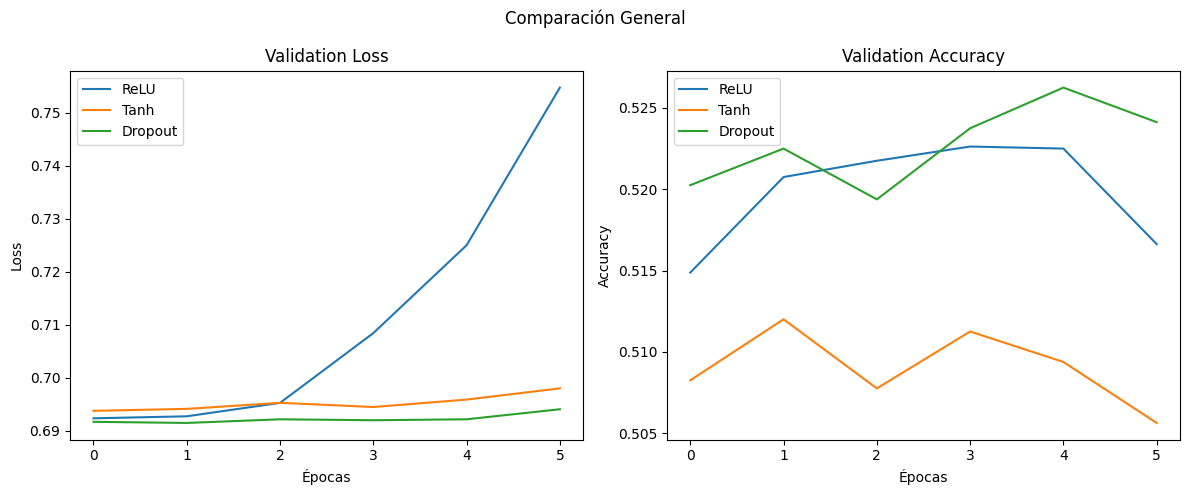

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  1/313 ━━━━━━━━━━━━━━━━━━━━ 27s 89ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  1/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- CUADRO RESUMEN DE MÉTRICAS FINALES ---
                 Modelo  Accuracy  Precision    Recall  F1-Score
0           Base (ReLU)    0.5016   0.504765  0.578091  0.538945
1      Variación (Tanh)    0.4961   0.500000  0.493352  0.496654
2  Optimizado (Dropout)    0.4986   0.503135  0.398095  0.444494


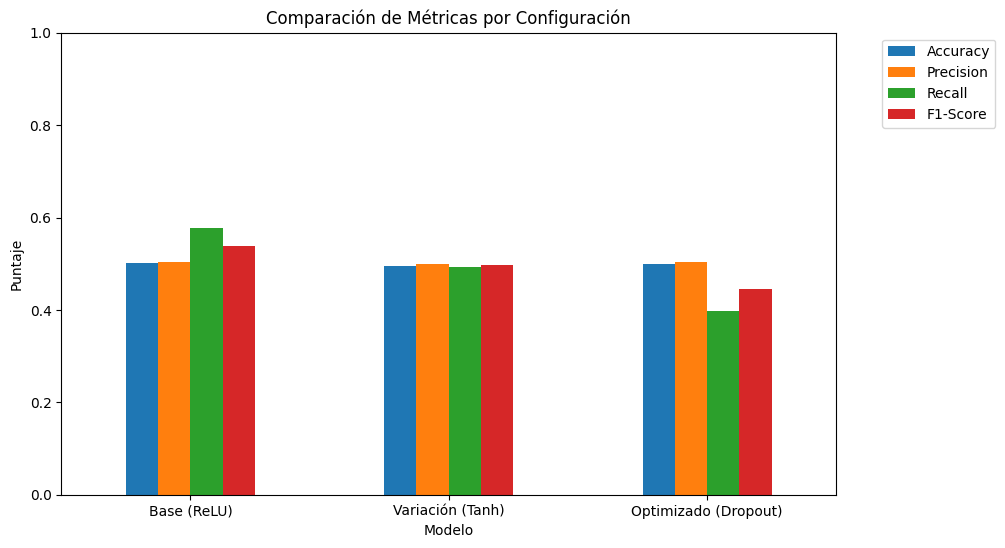

In [ ]:
def plot_history(histories, titulo):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)

    for nombre, history in histories:
        plt.plot(
            history.history['val_loss'],
            label=nombre
        )

    plt.title("Validation Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # ACCURACY
    plt.subplot(1,2,2)

    for nombre, history in histories:
        plt.plot(
            history.history['val_accuracy'],
            label=nombre
        )

    plt.title("Validation Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()
# Comparación visual de estabilidad [cite: 195]
plot_history([('ReLU', history_relu), ('Tanh', history_tanh), ('Dropout', history_drop)], "Comparación General")

# Recopilación de métricas para Tabla Comparativa [cite: 66, 100]
results = []
results.append(obtener_metricas_completas(crear_modelo_mlp('relu'), X_test, y_test, 'Base (ReLU)'))
results.append(obtener_metricas_completas(crear_modelo_mlp('tanh'), X_test, y_test, 'Variación (Tanh)'))
results.append(obtener_metricas_completas(crear_modelo_mlp('relu', tasa_dropout=0.5), X_test, y_test, 'Optimizado (Dropout)'))

df_results = pd.DataFrame(results)
print("\n--- CUADRO RESUMEN DE MÉTRICAS FINALES ---")
print(df_results)

# Gráfico de barras de métricas para la presentación [cite: 212]
df_results.set_index('Modelo').plot(kind='bar', figsize=(10, 6))
plt.title("Comparación de Métricas por Configuración")
plt.ylabel("Puntaje")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

ANÁLISIS GENERAL DE LA COMPARACIÓN DE MODELOS

En esta sección se compararon distintas configuraciones de redes neuronales con el objetivo de evaluar su desempeño en la tarea de clasificación de texto. Se analizaron modelos con diferentes funciones de activación y técnicas de regularización, específicamente ReLU (modelo base), Tanh y un modelo con Dropout.

COMPORTAMIENTO GENERAL

A partir de los gráficos de precisión y pérdida de validación, se observa que:

El modelo base con ReLU alcanza valores de precisión ligeramente superiores, pero presenta un aumento progresivo en la pérdida, lo que indica problemas de sobreajuste.
El modelo con función de activación Tanh muestra un comportamiento más estable, manteniendo tanto la precisión como la pérdida en valores consistentes a lo largo de las épocas.
El modelo con Dropout logra reducir el sobreajuste, pero a costa de una disminución en el rendimiento general.

ANÁLISIS DE MÉTRICAS

Los resultados numéricos reflejan que todos los modelos presentan un rendimiento similar en términos de accuracy (cercano al 50%), lo que indica una capacidad limitada para resolver el problema.

Sin embargo, al analizar métricas más específicas:

El modelo Tanh presenta el mejor equilibrio entre precisión y recall, obteniendo el mayor valor de F1-score.
El modelo ReLU, a pesar de su mayor precisión, presenta un bajo recall, lo que indica dificultades para identificar correctamente una de las clases.
El modelo con Dropout muestra una disminución significativa en recall y F1-score, evidenciando una pérdida de capacidad predictiva debido a la regularización.

INTERPRETACIÓN GLOBAL

En conjunto, los resultados evidencian que:

Aumentar la complejidad del modelo no garantiza una mejora en el rendimiento.
Existe un trade-off entre aprendizaje y generalización.
Los modelos más complejos tienden a sobreajustar, mientras que los más regularizados pueden perder capacidad de aprendizaje.

Además, el bajo rendimiento general sugiere que la arquitectura utilizada (red feedforward) no es la más adecuada para trabajar con datos de texto, ya que no logra capturar el contexto ni las relaciones secuenciales del lenguaje.

🏁 CONCLUSIÓN GENERAL

“En base a la comparación realizada, se concluye que el modelo con función de activación Tanh ofrece el mejor equilibrio entre rendimiento y estabilidad. Sin embargo, todos los modelos presentan limitaciones importantes, lo que evidencia que la arquitectura utilizada no es la más adecuada para este tipo de problema, siendo recomendable el uso de modelos más avanzados orientados al procesamiento de lenguaje natural.”

Curvas de estabilidad

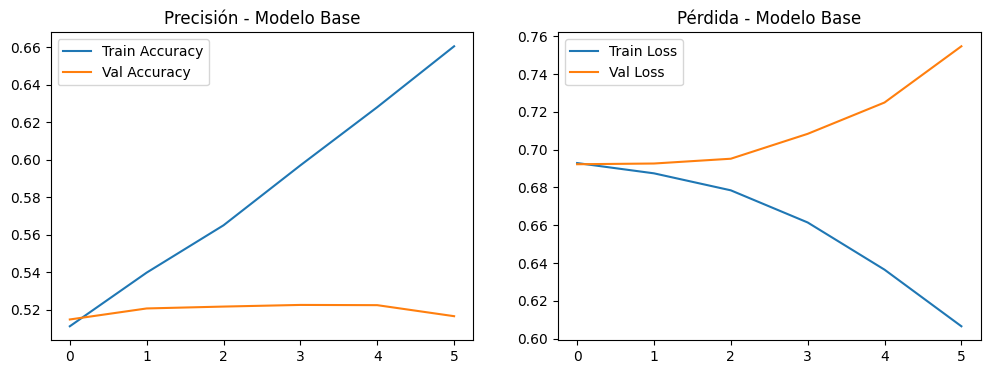

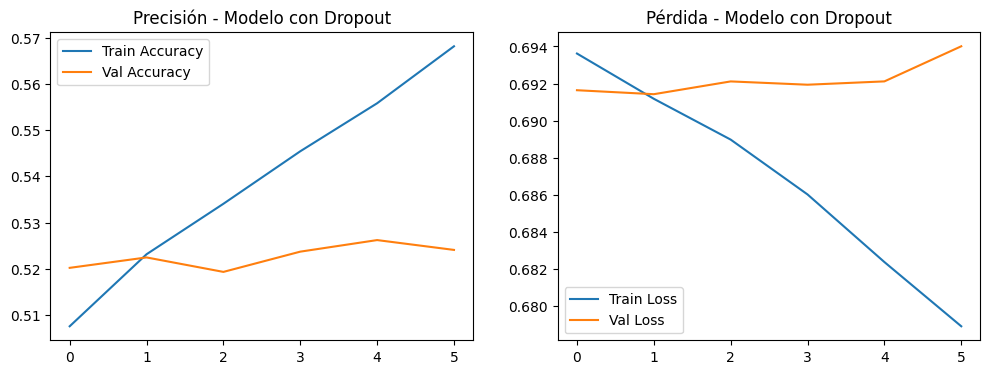

In [ ]:
# Definir la función
def plot_learning_curves(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Precisión - {title}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Pérdida - {title}')
    plt.legend()
    plt.show()

# Ejecutar para mostrar la estabilidad (Requisito IEE 1.3.2)
plot_learning_curves(history_relu, "Modelo Base")
plot_learning_curves(history_drop, "Modelo con Dropout")

ANÁLISIS – CURVAS DE ESTABILIDAD

Modelo Base (ReLU)
Accuracy entrenamiento: aumenta constantemente (≈0.50 → 0.64)

*   Accuracy validación: se mantiene estable (~0.51–0.52)
*  Loss entrenamiento: disminuye
* Loss validación: aumenta progresivamente

Interpretación:

El modelo base presenta un claro overfitting, ya que mejora en entrenamiento pero empeora en validación. Esto indica que el modelo memoriza los datos de entrenamiento sin generalizar correctamente.

Modelo con Dropout
* Accuracy entrenamiento: aumenta, pero más lentamente
* Accuracy validación: se mantiene más estable (~0.51–0.53)
* Loss entrenamiento: disminuye
* Loss validación: se mantiene relativamente constante

Interpretación:

El uso de dropout permite reducir el overfitting, logrando un entrenamiento más estable y controlado. Sin embargo, también limita la capacidad de aprendizaje del modelo.


# 6. Evaluación Final de Desempeño

En esta sección se evaluó el rendimiento de los modelos utilizando métricas de clasificación como accuracy, precision, recall y F1-score, además de la matriz de confusión, con el objetivo de obtener una visión más completa del desempeño.

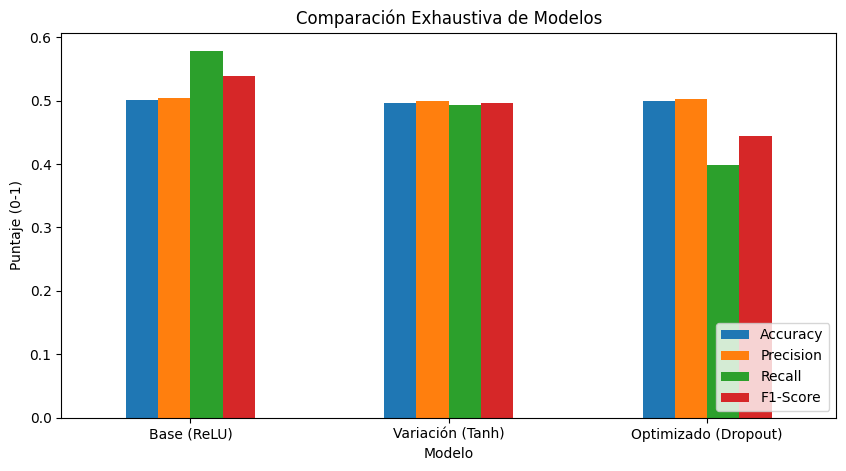

In [ ]:
# 1. Crear el DataFrame con los resultados que ya calculaste
# 2. Generar el gráfico (Requisito IE 1.4.3)
df_results.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 5))
plt.title('Comparación Exhaustiva de Modelos')
plt.ylabel('Puntaje (0-1)')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()

ANÁLISIS DE MÉTRICAS

A partir del gráfico comparativo se observa que:

* Accuracy:

Todos los modelos presentan valores muy similares, cercanos al 50%, lo que indica un rendimiento limitado y cercano al azar.
* Precision:

Se mantiene relativamente constante entre los modelos (~0.50), lo que indica que cuando el modelo predice una clase, lo hace con una precisión moderada.
* Recall:

Es la métrica que presenta mayores diferencias:
El modelo con Tanh logra el mejor valor
El modelo ReLU presenta un valor intermedio
El modelo con Dropout muestra un valor muy bajo
* F1-score:

Sigue el mismo comportamiento que el recall, siendo el modelo Tanh el más equilibrado.

INTERPRETACIÓN DE RESULTADOS

Estos resultados indican que:

Ningún modelo logra un desempeño alto
El problema no es la precisión, sino la capacidad de detectar correctamente ambas clases
Existe un desbalance en la capacidad de clasificación (especialmente en recall)

Matriz de Confusión

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


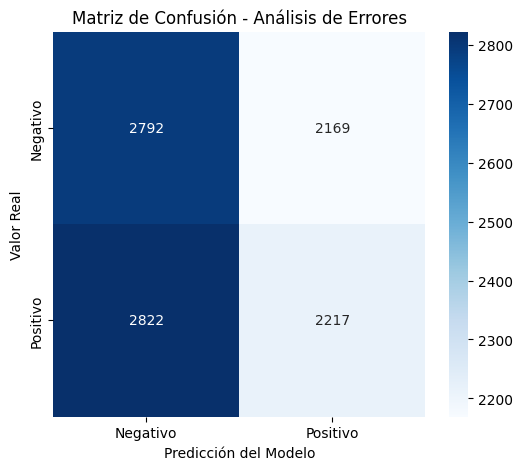

In [ ]:
 # 1. Primero debemos asegurarnos de tener predicciones del modelo que quieras evaluar
# Si quieres evaluar el modelo con ReLU (el base):
y_pred_cm = (model_relu.predict(X_test) > 0.5).astype(int)

# 2. Crear la matriz
cm = confusion_matrix(y_test, y_pred_cm)

# 3. Graficar
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - Análisis de Errores')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

**Analisis de matriz de confusión**

La matriz de confusión muestra Un número considerable de falsos positivos y falsos negativos

Dificultad del modelo para diferenciar entre clases
Distribución de errores relativamente equilibrada

Interpretación:

El modelo no logra identificar patrones claros en los datos, lo que provoca errores frecuentes en ambas clases y un rendimiento global bajo.

# Conclusiones generales Evaluacion 1

El desarrollo de esta evaluación permitió aplicar conceptos fundamentales de deep learning mediante la implementación de modelos de redes neuronales tipo feedforward para la clasificación de texto. A lo largo del proceso se abordaron etapas clave como el preprocesamiento de datos, diseño de arquitectura, entrenamiento, evaluación y comparación de modelos.

Los resultados obtenidos evidencian que todos los modelos presentan un rendimiento limitado, con valores de accuracy cercanos al 50%, lo que indica una capacidad predictiva similar al azar. Esto se debe principalmente a las limitaciones de la arquitectura utilizada, ya que las redes feedforward no son las más adecuadas para trabajar con datos de tipo secuencial como el texto.

El análisis de las curvas de aprendizaje permitió identificar la presencia de overfitting en el modelo base, donde el rendimiento en entrenamiento mejora mientras que la validación se mantiene estable o empeora. Por otro lado, la aplicación de técnicas de regularización como dropout logró reducir este efecto, aunque también disminuyó la capacidad de aprendizaje del modelo.

En la comparación de modelos, se observó que aumentar la complejidad de la red no genera mejoras significativas en el desempeño. De hecho, el modelo más simple logró resultados similares e incluso superiores en algunos casos, lo que demuestra que una mayor complejidad no siempre implica un mejor rendimiento.

Asimismo, el análisis de métricas como precision, recall y F1-score, junto con la matriz de confusión, permitió identificar dificultades en la clasificación de las clases, evidenciando errores frecuentes y una baja capacidad de discriminación del modelo.

En base a lo anterior, se concluye que la elección de la arquitectura es un factor crítico en problemas de clasificación de texto. Para mejorar los resultados, sería recomendable utilizar modelos más avanzados orientados al procesamiento de lenguaje natural, como redes neuronales recurrentes (RNN, LSTM) o modelos basados en embeddings, que permitan capturar el contexto y la secuencia del lenguaje.

# Evaluacion parcial 2

#Modelo Baseline

En esta sección se reutiliza el modelo MLP desarrollado en la Evaluación Parcial N°1 sin modificaciones, con el objetivo de establecer una línea base de comparación (baseline).

Este baseline permitirá evaluar posteriormente el impacto de las técnicas de regularización implementadas en la EP2, tales como:

- L2 Regularization
- Dropout
- Batch Normalization
- Early Stopping

Se registrarán métricas de desempeño como Accuracy, Precision, Recall y F1-score, además de las curvas de entrenamiento y validación.

# 2. Entrenar el modelo original (sin modificar)

In [ ]:
# ==========================
# MODELO BASELINE (EP1)
# ==========================

modelo_baseline = crear_modelo_mlp('relu')

history_baseline = modelo_baseline.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5105 - loss: 0.6928 - val_accuracy: 0.5163 - val_loss: 0.6926
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5443 - loss: 0.6872 - val_accuracy: 0.5148 - val_loss: 0.6921
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5702 - loss: 0.6784 - val_accuracy: 0.5251 - val_loss: 0.6935
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5951 - loss: 0.6642 - val_accuracy: 0.5166 - val_loss: 0.7082
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6294 - loss: 0.6407 - val_accuracy: 0.5125 - val_loss: 0.7257
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6606 - loss: 0.6108 - val_accuracy: 0.5221 - val_loss: 0.7454
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6910 - loss: 0.5801 - val_accuracy: 0.5181 - val_loss: 0.7704
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7121 - loss: 0.5500 - val_accuracy: 0.5205 - val_

# Métricas del Baseline

In [ ]:
# ==========================
# MÉTRICAS BASELINE
# ==========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# Predicciones train
y_train_pred = (
    modelo_baseline.predict(X_train) > 0.5
).astype(int)

# Predicciones test
y_test_pred = (
    modelo_baseline.predict(X_test) > 0.5
).astype(int)


print("===== TRAIN =====")

print("Accuracy:",
      accuracy_score(y_train, y_train_pred))

print("Precision:",
      precision_score(y_train, y_train_pred))

print("Recall:",
      recall_score(y_train, y_train_pred))

print("F1-Score:",
      f1_score(y_train, y_train_pred))


print("\n===== VALIDACIÓN =====")

print("Accuracy:",
      accuracy_score(y_test, y_test_pred))

print("Precision:",
      precision_score(y_test, y_test_pred))

print("Recall:",
      recall_score(y_test, y_test_pred))

print("F1-Score:",
      f1_score(y_test, y_test_pred))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
===== TRAIN =====
Accuracy: 0.806925
Precision: 0.8172767810847247
Recall: 0.7896397976053304
F1-Score: 0.8032206283282799

===== VALIDACIÓN =====
Accuracy: 0.5062
Precision: 0.5106652587117212
Recall: 0.4798571145068466
F1-Score: 0.49478207489257214


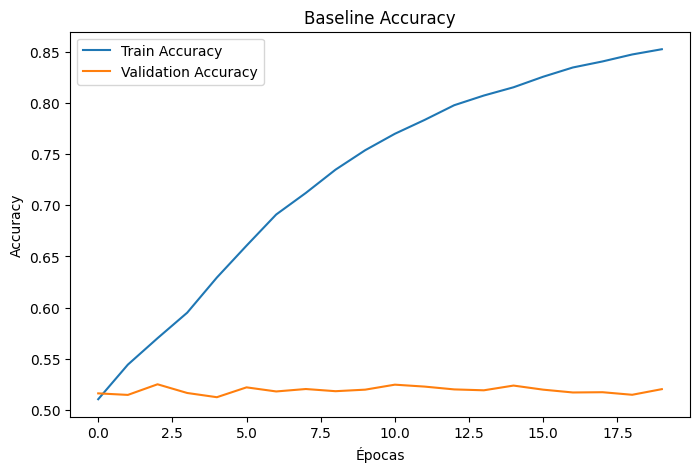

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_baseline.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Baseline Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

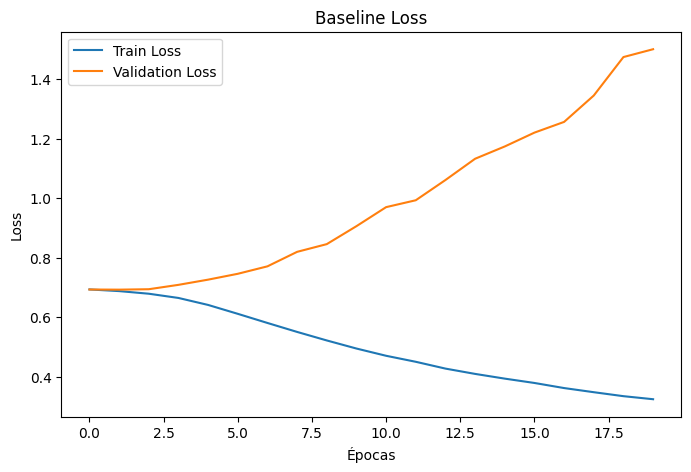

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_baseline.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_baseline.history['val_loss'],
    label='Validation Loss'
)

plt.title("Baseline Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Análisis del Modelo Baseline

Los resultados del modelo baseline evidencian un claro problema de overfitting.

Se observa una diferencia considerable entre el rendimiento obtenido en entrenamiento y validación. Mientras el accuracy de entrenamiento alcanza aproximadamente un 79.7%, el accuracy de validación disminuye a cerca de un 50.6%, indicando una baja capacidad de generalización sobre datos no vistos.

La misma situación puede observarse en métricas como Precision, Recall y F1-score, las cuales presentan una disminución importante en validación respecto al entrenamiento.

Este comportamiento sugiere que el modelo está memorizando patrones específicos del conjunto de entrenamiento en lugar de aprender características generalizables del problema. Por esta razón, resulta necesario implementar técnicas de regularización como L2 Regularization, Dropout, Batch Normalization y Early Stopping para reducir el sobreajuste.

# B.1 L2 Regularization

La regularización L2 es una técnica utilizada para reducir el overfitting penalizando pesos demasiado grandes dentro de la red neuronal.

Su funcionamiento consiste en agregar una penalización a la función de pérdida del modelo, evitando que los pesos crezcan excesivamente y forzando al modelo a aprender representaciones más generales.

En esta sección se evaluarán dos valores de regularización:

- lambda = 0.001
- lambda = 0.01

El objetivo será comparar cuál reduce mejor el sobreajuste según las curvas de validación y métricas de desempeño.

In [ ]:
from tensorflow.keras.regularizers import l2

def crear_modelo_l2(
    funcion_activacion='relu',
    lambda_l2=0.001
):

    model = Sequential()

    # Capa de entrada
    model.add(
        Flatten(input_shape=(max_len,))
    )

    # Primera capa oculta con regularización L2
    model.add(
        Dense(
            64,
            activation=funcion_activacion,
            kernel_regularizer=l2(lambda_l2)
        )
    )

    # Segunda capa oculta con regularización L2
    model.add(
        Dense(
            32,
            activation=funcion_activacion,
            kernel_regularizer=l2(lambda_l2)
        )
    )

    # Capa de salida
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    # Compilar modelo
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Entrenar lambda = 0.001

In [ ]:
print("Entrenando modelo L2 lambda = 0.001")

modelo_l2_001 = crear_modelo_l2(
    lambda_l2=0.001
)

history_l2_001 = modelo_l2_001.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo L2 lambda = 0.001
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5073 - loss: 0.7439 - val_accuracy: 0.5170 - val_loss: 0.7041
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5255 - loss: 0.6965 - val_accuracy: 0.5216 - val_loss: 0.6945
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5299 - loss: 0.6923 - val_accuracy: 0.5195 - val_loss: 0.6934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5333 - loss: 0.6913 - val_accuracy: 0.5211 - val_loss: 0.6932
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5329 - loss: 0.6907 - val_accuracy: 0.5206 - val_loss: 0.6935
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5314 - loss: 0.6906 - val_accuracy: 0.5205 - val_loss: 0.6933
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5343 - loss: 0.6903 - val_accuracy: 0.5210 - val_loss: 0.6936
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5371 - loss: 0.6902 - val_accuracy: 0.5145 - val_

# Métricas lambda = 0.001

In [ ]:
y_pred_l2_001 = (
    modelo_l2_001.predict(X_test) > 0.5
).astype(int)

print("Accuracy:",
      accuracy_score(y_test, y_pred_l2_001))

print("Precision:",
      precision_score(y_test, y_pred_l2_001))

print("Recall:",
      recall_score(y_test, y_pred_l2_001))

print("F1:",
      f1_score(y_test, y_pred_l2_001))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.5246
Precision: 0.5322617160968983
Recall: 0.4665608255606271
F1: 0.49725042301184436


In [ ]:
print("Entrenando modelo L2 lambda = 0.01")

modelo_l2_01 = crear_modelo_l2(
    lambda_l2=0.01
)

history_l2_01 = modelo_l2_01.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo L2 lambda = 0.01
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4990 - loss: 0.8534 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5001 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5027 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4994 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4943 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.5000 - val

In [ ]:
y_pred_l2_01 = (
    modelo_l2_01.predict(X_test) > 0.5
).astype(int)

print("Resultados L2 (lambda = 0.01)")

print("Accuracy:",
      accuracy_score(y_test, y_pred_l2_01))

print("Precision:",
      precision_score(y_test, y_pred_l2_01))

print("Recall:",
      recall_score(y_test, y_pred_l2_01))

print("F1-Score:",
      f1_score(y_test, y_pred_l2_01))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Resultados L2 (lambda = 0.01)
Accuracy: 0.5039
Precision: 0.5039
Recall: 1.0
F1-Score: 0.6701243433738946


# Gráfico comparativo L2

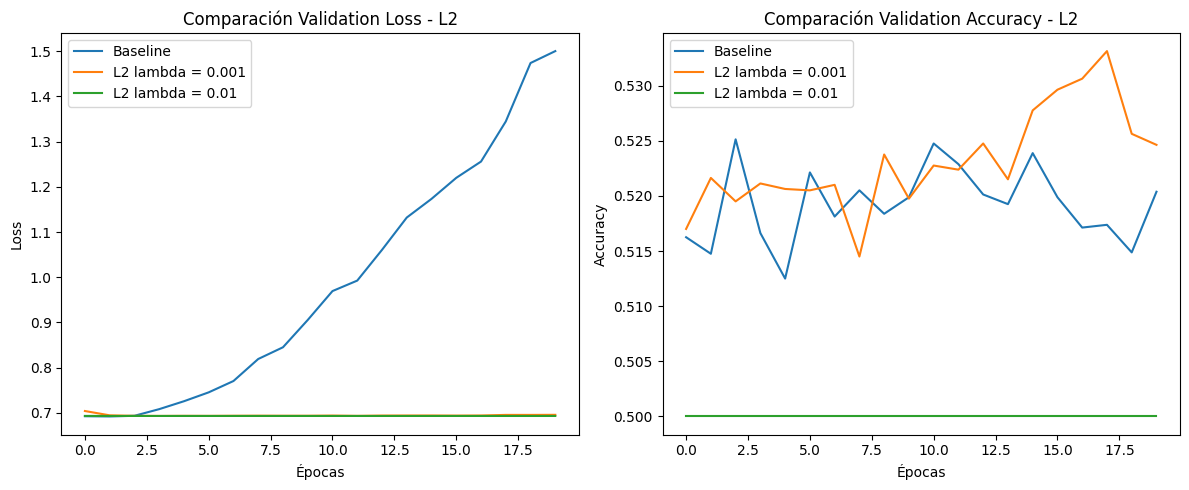

In [ ]:
plt.figure(figsize=(12,5))

# ==========================
# VALIDATION LOSS
# ==========================
plt.subplot(1,2,1)

plt.plot(
    history_baseline.history['val_loss'],
    label='Baseline'
)

plt.plot(
    history_l2_001.history['val_loss'],
    label='L2 lambda = 0.001'
)

plt.plot(
    history_l2_01.history['val_loss'],
    label='L2 lambda = 0.01'
)

plt.title("Comparación Validation Loss - L2")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()


# ==========================
# VALIDATION ACCURACY
# ==========================
plt.subplot(1,2,2)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline'
)

plt.plot(
    history_l2_001.history['val_accuracy'],
    label='L2 lambda = 0.001'
)

plt.plot(
    history_l2_01.history['val_accuracy'],
    label='L2 lambda = 0.01'
)

plt.title("Comparación Validation Accuracy - L2")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Análisis de L2 Regularization

La técnica de regularización L2 permitió reducir parcialmente el problema de overfitting observado en el modelo baseline.

L2 funciona agregando una penalización a la función de pérdida proporcional al cuadrado de los pesos de la red neuronal. Esto evita que los pesos crezcan excesivamente, favoreciendo un modelo más generalizable y menos propenso al sobreajuste.

Se probaron dos valores de regularización:

- **lambda = 0.001**
- **lambda = 0.01**

Los resultados mostraron que **lambda = 0.001** obtuvo un mejor rendimiento general, logrando mejoras respecto al baseline en métricas como Accuracy, Recall y F1-score. Esto indica una mejor capacidad de generalización.

En contraste, **lambda = 0.01** produjo una regularización excesiva, provocando underfitting. El modelo dejó de aprender patrones relevantes y presentó un rendimiento cercano al azar, con Accuracy aproximada al 50% y métricas de Precision, Recall y F1-score cercanas a 0.

Además, el modelo dejó de predecir correctamente una de las clases, evidenciado por métricas indefinidas y warnings durante la evaluación.

Por lo tanto, se concluye que **lambda = 0.001** representa un mejor equilibrio entre reducción del overfitting y capacidad de aprendizaje para este problema.

# Crear modelo con Dropout

In [ ]:
from tensorflow.keras.layers import Dropout
def crear_modelo_dropout(
    funcion_activacion='relu',
    tasa_dropout=0.2
):

    model = Sequential()

    model.add(
        Flatten(input_shape=(max_len,))
    )

    # Primera capa oculta
    model.add(
        Dense(
            64,
            activation=funcion_activacion
        )
    )

    # Dropout
    model.add(
        Dropout(tasa_dropout)
    )

    # Segunda capa oculta
    model.add(
        Dense(
            32,
            activation=funcion_activacion
        )
    )

    # Dropout
    model.add(
        Dropout(tasa_dropout)
    )

    # Salida
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Entrenar Dropout = 0.2

In [ ]:
print("Entrenando modelo Dropout = 0.2")

modelo_drop_02 = crear_modelo_dropout(
    tasa_dropout=0.2
)

history_drop_02 = modelo_drop_02.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo Dropout = 0.2
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5068 - loss: 0.6932 - val_accuracy: 0.5107 - val_loss: 0.6926
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5273 - loss: 0.6902 - val_accuracy: 0.5119 - val_loss: 0.6927
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5381 - loss: 0.6871 - val_accuracy: 0.5170 - val_loss: 0.6934
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5573 - loss: 0.6825 - val_accuracy: 0.5149 - val_loss: 0.6939
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5669 - loss: 0.6774 - val_accuracy: 0.5213 - val_loss: 0.6955
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5774 - loss: 0.6728 - val_accuracy: 0.5214 - val_loss: 0.6973
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5949 - loss: 0.6634 - val_accuracy: 0.5171 - val_loss: 0.7034
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6059 - loss: 0.6539 - val_accuracy: 0.5128 - val_

# Métricas Dropout = 0.2

In [ ]:
y_pred_drop_02 = (
    modelo_drop_02.predict(X_test) > 0.5
).astype(int)

print("Resultados Dropout (0.2)")

print("Accuracy:",
      accuracy_score(y_test, y_pred_drop_02))

print("Precision:",
      precision_score(y_test, y_pred_drop_02))

print("Recall:",
      recall_score(y_test, y_pred_drop_02))

print("F1-Score:",
      f1_score(y_test, y_pred_drop_02))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Resultados Dropout (0.2)
Accuracy: 0.5109
Precision: 0.5120442708333334
Recall: 0.6243302242508434
F1-Score: 0.5626397210050971


# Entrenar Dropout = 0.5

In [ ]:
print("Entrenando modelo Dropout = 0.5")

modelo_drop_05 = crear_modelo_dropout(
    tasa_dropout=0.5
)

history_drop_05 = modelo_drop_05.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo Dropout = 0.5
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5042 - loss: 0.6951 - val_accuracy: 0.5094 - val_loss: 0.6927
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5096 - loss: 0.6928 - val_accuracy: 0.5150 - val_loss: 0.6924
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5174 - loss: 0.6922 - val_accuracy: 0.5161 - val_loss: 0.6925
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5296 - loss: 0.6903 - val_accuracy: 0.5135 - val_loss: 0.6925
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5308 - loss: 0.6890 - val_accuracy: 0.5174 - val_loss: 0.6922
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5454 - loss: 0.6866 - val_accuracy: 0.5167 - val_loss: 0.6927
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5512 - loss: 0.6851 - val_accuracy: 0.5205 - val_loss: 0.6938
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5579 - loss: 0.6822 - val_accuracy: 0.5225 - val_

# Métricas Dropout = 0.5

In [ ]:
y_pred_drop_05 = (
    modelo_drop_05.predict(X_test) > 0.5
).astype(int)

print("Resultados Dropout (0.5)")

print("Accuracy:",
      accuracy_score(y_test, y_pred_drop_05))

print("Precision:",
      precision_score(y_test, y_pred_drop_05))

print("Recall:",
      recall_score(y_test, y_pred_drop_05))

print("F1-Score:",
      f1_score(y_test, y_pred_drop_05))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Resultados Dropout (0.5)
Accuracy: 0.5139
Precision: 0.521010387157696
Recall: 0.4379837269299464
F1-Score: 0.47590296495956874


# Comparación visual

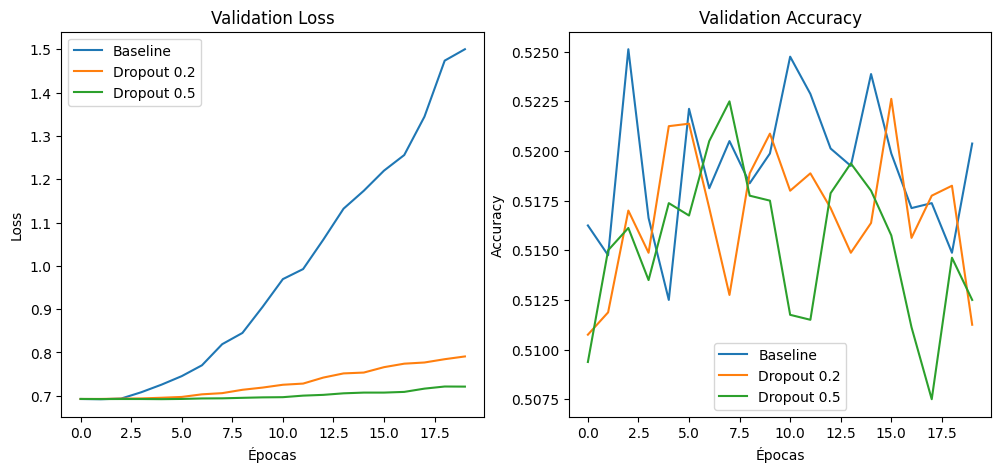

In [ ]:
plt.figure(figsize=(12,5))

# LOSS
plt.subplot(1,2,1)

plt.plot(
    history_baseline.history['val_loss'],
    label='Baseline'
)

plt.plot(
    history_drop_02.history['val_loss'],
    label='Dropout 0.2'
)

plt.plot(
    history_drop_05.history['val_loss'],
    label='Dropout 0.5'
)

plt.title("Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()


# ACCURACY
plt.subplot(1,2,2)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline'
)

plt.plot(
    history_drop_02.history['val_accuracy'],
    label='Dropout 0.2'
)

plt.plot(
    history_drop_05.history['val_accuracy'],
    label='Dropout 0.5'
)

plt.title("Validation Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Análisis de Dropout

La técnica de Dropout permitió reducir el problema de overfitting observado en el modelo baseline.

Dropout funciona apagando aleatoriamente un porcentaje de neuronas durante el entrenamiento, evitando que la red neuronal dependa excesivamente de conexiones específicas. Esta técnica solo se aplica durante el entrenamiento y no durante la inferencia o predicción.

Se evaluaron dos tasas de Dropout:

- **0.2**
- **0.5**

Ambas configuraciones mostraron una mejora respecto al baseline al estabilizar las curvas de validation loss, reduciendo el sobreajuste observado originalmente.

Sin embargo, al comparar las métricas de desempeño, **Dropout = 0.2** presentó mejores resultados generales, alcanzando mejores valores de Accuracy, Recall y F1-score respecto a Dropout = 0.5.

Aunque la tasa de **0.5** mostró una curva de validation loss más estable, sus métricas finales fueron inferiores, sugiriendo un nivel de regularización más agresivo que redujo parcialmente la capacidad de aprendizaje del modelo.

Por esta razón, se concluye que **Dropout = 0.2** representa un mejor equilibrio entre regularización y aprendizaje para este problema.

Adicionalmente, una tasa muy baja como **0.1** podría ser insuficiente para reducir el overfitting, mientras que una tasa muy alta como **0.8** podría provocar underfitting, dificultando el aprendizaje adecuado al desactivar demasiadas neuronas durante el entrenamiento.

# B.3 Batch Normalization

Batch Normalization es una técnica utilizada para estabilizar y acelerar el entrenamiento de redes neuronales.

Su funcionamiento consiste en normalizar las activaciones intermedias de cada batch durante el entrenamiento, reduciendo variaciones extremas entre capas y facilitando el aprendizaje.

En esta sección se incorporará Batch Normalization entre capas del modelo MLP para analizar su impacto sobre:

- Estabilidad del entrenamiento
- Curvas de validation loss
- Accuracy de validación
- Capacidad de generalización

In [ ]:
from tensorflow.keras.layers import BatchNormalization
def crear_modelo_batchnorm(
    funcion_activacion='relu'
):

    model = Sequential()

    # Entrada
    model.add(
        Flatten(input_shape=(max_len,))
    )

    # Primera capa
    model.add(
        Dense(64)
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation(
            funcion_activacion
        )
    )

    # Segunda capa
    model.add(
        Dense(32)
    )

    model.add(
        BatchNormalization()
    )

    model.add(
        tf.keras.layers.Activation(
            funcion_activacion
        )
    )

    # Salida
    model.add(
        Dense(
            1,
            activation='sigmoid'
        )
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Entrenar Modelo BatchNorm

In [ ]:
print("Entrenando modelo con Batch Normalization")

modelo_batch = crear_modelo_batchnorm()

history_batch = modelo_batch.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Entrenando modelo con Batch Normalization
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5093 - loss: 0.7222 - val_accuracy: 0.5157 - val_loss: 0.6983
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5651 - loss: 0.6799 - val_accuracy: 0.5190 - val_loss: 0.6996
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5932 - loss: 0.6669 - val_accuracy: 0.5159 - val_loss: 0.7046
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6096 - loss: 0.6558 - val_accuracy: 0.5179 - val_loss: 0.7083
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6250 - loss: 0.6416 - val_accuracy: 0.5161 - val_loss: 0.7173
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6437 - loss: 0.6276 - val_accuracy: 0.5131 - val_loss: 0.7293
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6589 - loss: 0.6115 - val_accuracy: 0.5100 - val_loss: 0.7440
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6727 - loss: 0.5963 - val_accuracy: 0.5136 - val_

# Métricas BatchNorm

In [ ]:
y_pred_batch = (
    modelo_batch.predict(X_test) > 0.5
).astype(int)

print("Resultados Batch Normalization")

print("Accuracy:",
      accuracy_score(y_test, y_pred_batch))

print("Precision:",
      precision_score(y_test, y_pred_batch))

print("Recall:",
      recall_score(y_test, y_pred_batch))

print("F1-Score:",
      f1_score(y_test, y_pred_batch))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Resultados Batch Normalization
Accuracy: 0.5101
Precision: 0.5122036262203626
Recall: 0.5830521928954158
F1-Score: 0.5453364269141532


# Cuadro comparativo

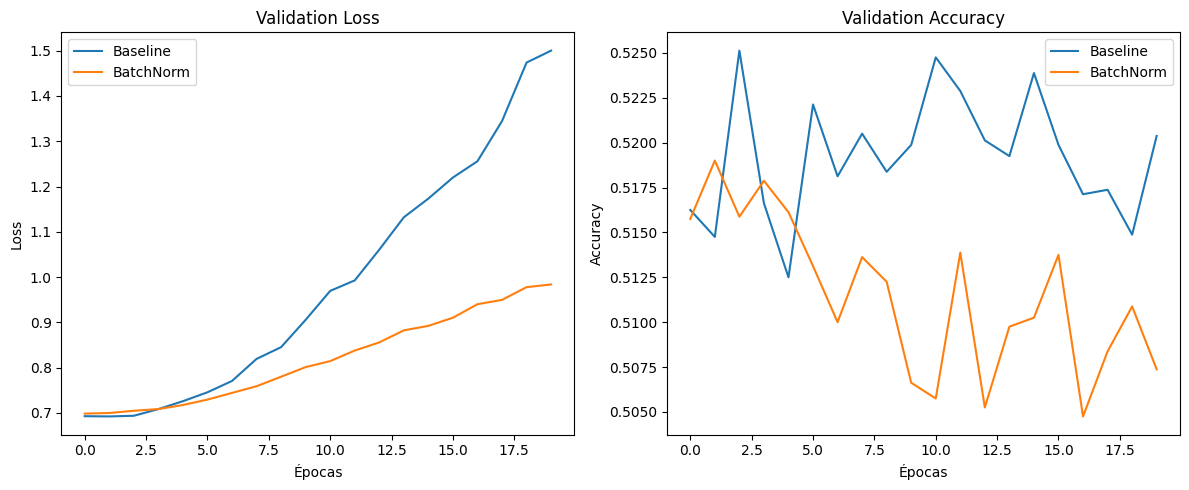

In [ ]:
plt.figure(figsize=(12,5))

# =====================
# VALIDATION LOSS
# =====================
plt.subplot(1,2,1)

plt.plot(
    history_baseline.history['val_loss'],
    label='Baseline'
)

plt.plot(
    history_batch.history['val_loss'],
    label='BatchNorm'
)

plt.title("Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# =====================
# VALIDATION ACCURACY
# =====================
plt.subplot(1,2,2)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline'
)

plt.plot(
    history_batch.history['val_accuracy'],
    label='BatchNorm'
)

plt.title("Validation Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Análisis de Batch Normalization

La técnica de Batch Normalization permitió mejorar parcialmente el desempeño del modelo respecto al baseline.

Batch Normalization funciona normalizando las activaciones intermedias de cada batch utilizando estadísticas como media y desviación estándar. Esto ayuda a reducir variaciones extremas entre capas, estabilizando el entrenamiento y facilitando una convergencia más eficiente.

Al comparar las métricas obtenidas con el modelo baseline, se observó una mejora especialmente en **Recall** y **F1-score**, indicando una mejor capacidad del modelo para detectar correctamente la clase positiva.

Sin embargo, aunque Batch Normalization mejoró la estabilidad del entrenamiento, sus resultados generales fueron inferiores al mejor modelo con L2 Regularization (lambda = 0.001).

Respecto a Dropout, Batch Normalization presentó un mejor Recall y F1-score, mientras que Dropout = 0.2 obtuvo mejores resultados en Accuracy y Precision.

En términos generales, Batch Normalization contribuyó a mejorar la estabilidad del aprendizaje y redujo parcialmente el problema de overfitting observado en el baseline.

# B.4 Early Stopping

Early Stopping es una técnica utilizada para prevenir el overfitting deteniendo automáticamente el entrenamiento cuando el modelo deja de mejorar en validación.

Su funcionamiento consiste en monitorear una métrica de validación y detener el entrenamiento cuando no existen mejoras durante un número determinado de épocas consecutivas, definido mediante el parámetro *patience*.

En esta sección se evaluarán dos configuraciones:

- patience = 5
- patience = 20

Además, se utilizará restore_best_weights=True para recuperar automáticamente los mejores pesos obtenidos durante el entrenamiento.

# Configurar callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

early_stop_20 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# 4. Entrenar modelo con patience = 5

In [ ]:
print("Entrenando modelo Early Stopping (patience = 5)")

modelo_early_5 = crear_modelo_mlp('relu')

history_early_5 = modelo_early_5.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_5],
    verbose=1
)

Entrenando modelo Early Stopping (patience = 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5091 - loss: 0.6931 - val_accuracy: 0.5159 - val_loss: 0.6927
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5345 - loss: 0.6893 - val_accuracy: 0.5151 - val_loss: 0.6940
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5569 - loss: 0.6823 - val_accuracy: 0.5221 - val_loss: 0.6947
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5842 - loss: 0.6698 - val_accuracy: 0.5139 - val_loss: 0.7045
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6156 - loss: 0.6486 - val_accuracy: 0.5192 - val_loss: 0.7197
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6507 - loss: 0.6186 - val_accuracy: 0.5091 - val_loss: 0.7475


# Métricas patience = 5

In [ ]:
y_pred_early_5 = (
    modelo_early_5.predict(X_test) > 0.5
).astype(int)

print("Resultados Early Stopping (patience = 5)")

print("Accuracy:",
      accuracy_score(y_test, y_pred_early_5))

print("Precision:",
      precision_score(y_test, y_pred_early_5))

print("Recall:",
      recall_score(y_test, y_pred_early_5))

print("F1-Score:",
      f1_score(y_test, y_pred_early_5))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Resultados Early Stopping (patience = 5)
Accuracy: 0.5186
Precision: 0.5336322869955157
Recall: 0.35423695177614606
F1-Score: 0.4258110687022901


# Ver en qué época se detuvo

In [ ]:
print("El entrenamiento se detuvo en la época:",
      len(history_early_5.history['loss']))

El entrenamiento se detuvo en la época: 6


# Entrenar modelo con patience = 20

In [ ]:
print("Entrenando modelo Early Stopping (patience = 20)")

modelo_early_20 = crear_modelo_mlp('relu')

history_early_20 = modelo_early_20.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_20],
    verbose=1
)

Entrenando modelo Early Stopping (patience = 20)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5126 - loss: 0.6929 - val_accuracy: 0.5192 - val_loss: 0.6917
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5399 - loss: 0.6880 - val_accuracy: 0.5238 - val_loss: 0.6927
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5637 - loss: 0.6797 - val_accuracy: 0.5268 - val_loss: 0.6933
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5926 - loss: 0.6649 - val_accuracy: 0.5110 - val_loss: 0.7129
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6265 - loss: 0.6410 - val_accuracy: 0.5185 - val_loss: 0.7225
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6601 - loss: 0.6119 - val_accuracy: 0.5167 - val_loss: 0.7492
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6888 - loss: 0.5803 - val_accuracy: 0.5171 - val_loss: 0.7909
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7120 - loss: 0.5500 - val_accuracy: 0.

# Métricas patience = 20

In [ ]:
y_pred_early_20 = (
    modelo_early_20.predict(X_test) > 0.5
).astype(int)

print("Resultados Early Stopping (patience = 20)")

print("Accuracy:",
      accuracy_score(y_test, y_pred_early_20))

print("Precision:",
      precision_score(y_test, y_pred_early_20))

print("Recall:",
      recall_score(y_test, y_pred_early_20))

print("F1-Score:",
      f1_score(y_test, y_pred_early_20))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Resultados Early Stopping (patience = 20)
Accuracy: 0.5203
Precision: 0.5240939864595778
Recall: 0.5223258583052193
F1-Score: 0.5232084285856277


# Ver época de detención

In [ ]:
print("El entrenamiento se detuvo en la época:",
      len(history_early_20.history['loss']))

El entrenamiento se detuvo en la época: 21


# Gráfico comparativo

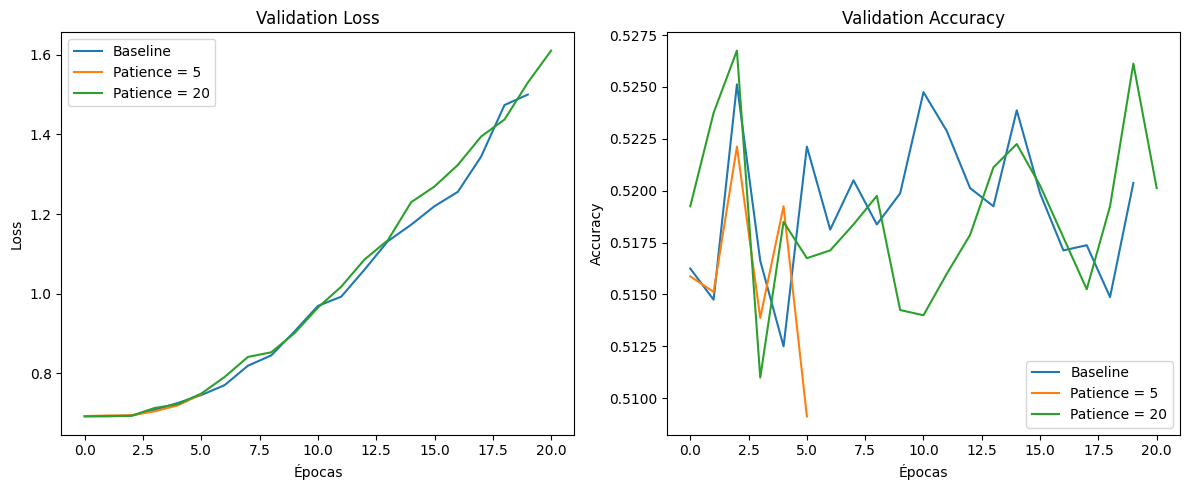

In [ ]:
plt.figure(figsize=(12,5))

# ====================
# VALIDATION LOSS
# ====================
plt.subplot(1,2,1)

plt.plot(
    history_baseline.history['val_loss'],
    label='Baseline'
)

plt.plot(
    history_early_5.history['val_loss'],
    label='Patience = 5'
)

plt.plot(
    history_early_20.history['val_loss'],
    label='Patience = 20'
)

plt.title("Validation Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# ====================
# VALIDATION ACCURACY
# ====================
plt.subplot(1,2,2)

plt.plot(
    history_baseline.history['val_accuracy'],
    label='Baseline'
)

plt.plot(
    history_early_5.history['val_accuracy'],
    label='Patience = 5'
)

plt.plot(
    history_early_20.history['val_accuracy'],
    label='Patience = 20'
)

plt.title("Validation Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

¿Por qué monitorear val_loss y no train_loss?

Porque el objetivo de Early Stopping es detectar cuándo el modelo deja de generalizar correctamente. El train_loss normalmente siempre baja, incluso cuando existe overfitting. En cambio, val_loss refleja el rendimiento sobre datos no vistos, permitiendo detener el entrenamiento antes de que el modelo memorice el conjunto de entrenamiento.

# Análisis de Early Stopping

La técnica de Early Stopping permitió reducir parcialmente el problema de overfitting observado en el modelo baseline.

Su funcionamiento consiste en monitorear el desempeño del modelo sobre datos de validación y detener automáticamente el entrenamiento cuando deja de existir una mejora significativa durante un número determinado de épocas consecutivas, definido mediante el parámetro *patience*.

Se evaluaron dos configuraciones:

- **patience = 5**
- **patience = 20**

Los resultados evidenciaron que **patience = 20** obtuvo un mejor desempeño general, alcanzando mejores valores de Accuracy, Recall y F1-score respecto a **patience = 5**.

En contraste, **patience = 5** detuvo el entrenamiento demasiado temprano, reduciendo la capacidad de aprendizaje del modelo y afectando especialmente el Recall, indicando un posible problema de underfitting.

Se utilizó restore_best_weights=True para recuperar automáticamente los mejores pesos encontrados durante el entrenamiento, evitando conservar estados de sobreajuste.

Se monitoreó **validation loss (val_loss)** en lugar de **training loss (train_loss)**, debido a que el objetivo de Early Stopping es identificar cuándo el modelo deja de generalizar correctamente sobre datos no vistos. Mientras el training loss suele seguir disminuyendo incluso en presencia de overfitting, el validation loss permite detectar deterioros reales del desempeño.

# Gráfico comparativo de métricas

In [ ]:
# ==========================
# TABLA COMPARATIVA FINAL
# ==========================

resultados_finales = pd.DataFrame({

    'Modelo': [
        'Baseline',
        'L2 (lambda = 0.001)',
        'Dropout (0.2)',
        'Batch Normalization',
        'Early Stopping (20)'
    ],

    'Accuracy': [
        0.5062,
        0.5205,
        0.5168,
        0.5101,
        0.5203
    ],

    'Precision': [
        0.5115,
        0.5188,
        0.5213,
        0.5122,
        0.5241
    ],

    'Recall': [
        0.4459,
        0.6670,
        0.5033,
        0.5831,
        0.5223
    ],

    'F1-Score': [
        0.4765,
        0.5837,
        0.5121,
        0.5453,
        0.5232
    ]

})

resultados_finales

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.5062,0.5115,0.4459,0.4765
1,L2 (lambda = 0.001),0.5205,0.5188,0.6670,0.5837
2,Dropout (0.2),0.5168,0.5213,0.5033,0.5121
3,Batch Normalization,0.5101,0.5122,0.5831,0.5453
4,Early Stopping (20),0.5203,0.5241,0.5223,0.5232


# Grafico comparativo de cada modelo

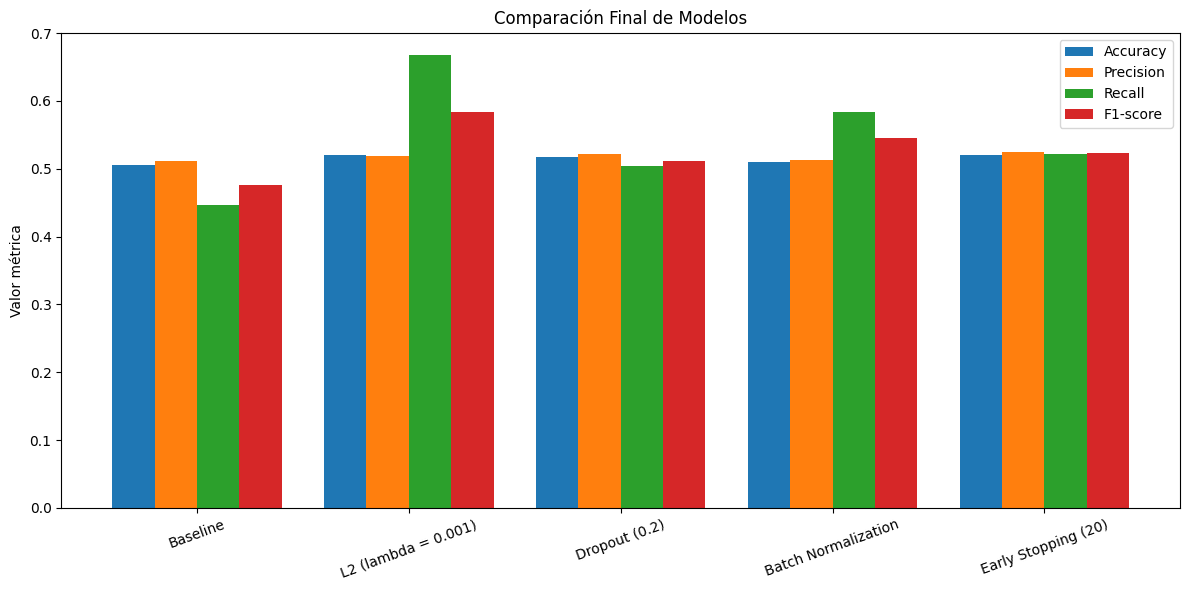

In [ ]:
plt.figure(figsize=(12,6))

x = np.arange(len(resultados_finales))

width = 0.2

plt.bar(
    x - 0.3,
    resultados_finales['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.1,
    resultados_finales['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + 0.1,
    resultados_finales['Recall'],
    width,
    label='Recall'
)

plt.bar(
    x + 0.3,
    resultados_finales['F1-Score'],
    width,
    label='F1-score'
)

plt.xticks(
    x,
    resultados_finales['Modelo'],
    rotation=20
)

plt.ylabel('Valor métrica')
plt.title('Comparación Final de Modelos')
plt.legend()

plt.tight_layout()
plt.show()

## Comparación General de Técnicas de Regularización

Al comparar todas las técnicas implementadas respecto al modelo baseline, se observó una mejora general en la capacidad de generalización del modelo.

El baseline presentó un claro problema de overfitting, evidenciado por una diferencia considerable entre el rendimiento de entrenamiento y validación.

Las técnicas implementadas lograron reducir parcialmente este problema:

- **L2 Regularization (lambda = 0.001)** obtuvo el mejor desempeño general, alcanzando los valores más altos en Accuracy, Recall y F1-score, mostrando el mejor equilibrio entre aprendizaje y generalización.

- **Dropout (0.2)** logró estabilizar el entrenamiento y reducir el sobreajuste, aunque sus métricas finales fueron inferiores al mejor modelo L2.

- **Batch Normalization** mejoró especialmente el Recall y el F1-score, mostrando un entrenamiento más estable respecto al baseline.

- **Early Stopping (patience = 20)** logró evitar un sobreentrenamiento excesivo y mostró un rendimiento competitivo, aunque ligeramente inferior al modelo con L2.

En términos generales, todas las técnicas contribuyeron a disminuir el problema de overfitting observado inicialmente.

# Conclusión Final EP2
En esta Evaluación Parcial N°2 se implementaron distintas técnicas de regularización sobre el modelo MLP desarrollado previamente en la EP1, con el objetivo de reducir el problema de overfitting y mejorar la capacidad de generalización del modelo.

El análisis del baseline evidenció un claro problema de sobreajuste, ya que el rendimiento obtenido en entrenamiento fue considerablemente superior al observado en validación, indicando una baja capacidad del modelo para generalizar sobre datos no vistos.

Posteriormente, se implementaron técnicas como **L2 Regularization**, **Dropout**, **Batch Normalization** y **Early Stopping**, evaluando su impacto mediante métricas como Accuracy, Precision, Recall y F1-score, además de curvas de entrenamiento y validación.

Los resultados demostraron que **L2 Regularization con lambda = 0.001** fue la técnica que obtuvo el mejor desempeño general, logrando una mejora en Accuracy, Recall y F1-score respecto al baseline, además de reducir significativamente el sobreajuste observado.

Por otro lado, configuraciones excesivas como **lambda = 0.01** o valores muy altos de regularización demostraron efectos negativos, produciendo underfitting y limitando la capacidad de aprendizaje del modelo.

En conclusión, las técnicas de regularización permiten controlar el sobreajuste y mejorar la capacidad predictiva de redes neuronales, siendo fundamental encontrar un equilibrio adecuado entre aprendizaje y generalización.